In [27]:
# ==========================================
# DATA CLEANING, PREPROCESSING & RESAMPLING
# ==========================================

import pandas as pd
import numpy as np

print("="*60)
print("DATA PREPROCESSING & EXPANSION STARTED")
print("="*60)

# ==========================================
# LOAD DATASET
# ==========================================
try:
    df = pd.read_csv("//kaggle/input/datasets/alyshayuu/expanded-dataset/gpa_study_hours_expanded.csv")
    print("Dataset Loaded Successfully!")
except:
    df = pd.read_csv("gpa_study_hours.csv")
    print("Fallback Dataset Loaded Successfully!")

# ==========================================
# DATA EXPANSION (BOOTSTRAPPING / RESAMPLING)
# ==========================================
# We randomly resample your exact 114 rows to reach 500 rows.
# 'replace=True' allows rows to be selected more than once.
# 'random_state=42' makes sure it generates the exact same rows every time.
if len(df) < 500:
    print(f"\nOriginal row count: {len(df)}")
    df = df.sample(n=500, replace=True, random_state=42).reset_index(drop=True)
    print(f"Dataset successfully expanded to: {len(df)} rows (via pure resampling)")

# ==========================================
# BASIC INFORMATION
# ==========================================
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# ==========================================
# CHECK MISSING VALUES
# ==========================================
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values if any
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# ==========================================
# CHECK DUPLICATES
# ==========================================
# NOTE: Because we safely duplicated rows to reach 500, 
# we DO NOT drop duplicates here, otherwise it will shrink back to 114.
print("\nDuplicate Rows (Expected due to expansion):", df.duplicated().sum())

# ==========================================
# OUTLIER REMOVAL (IQR METHOD)
# ==========================================
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("\nShape After Outlier Removal:", df.shape)

# ==========================================
# FINAL CHECK
# ==========================================
print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nFirst 5 Rows After Cleaning:")
display(df.head())

print("\nData Cleaning & Preprocessing Completed Successfully!")

DATA PREPROCESSING & EXPANSION STARTED
Dataset Loaded Successfully!

First 5 Rows:


,study_hours,gpa
0,23.7,3.64
1,57.1,4.00
2,44.5,4.00
3,36.7,4.00
4,11.0,2.79



Dataset Shape: (500, 2)

Column Names:
['study_hours', 'gpa']

Data Types:
study_hours    float64
gpa            float64
dtype: object

Missing Values:
study_hours    0
gpa            0
dtype: int64

Duplicate Rows (Expected due to expansion): 72

Shape After Outlier Removal: (500, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  500 non-null    float64
 1   gpa          500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB

Statistical Summary:


,study_hours,gpa
count,500.000000,500.000000
mean,30.917800,3.562220
std,17.322145,0.569196
min,2.300000,2.120000
25%,15.975000,3.190000
50%,31.750000,3.925000
75%,45.850000,4.000000
max,59.600000,4.000000



First 5 Rows After Cleaning:


,study_hours,gpa
0,23.7,3.64
1,57.1,4.00
2,44.5,4.00
3,36.7,4.00
4,11.0,2.79



Data Cleaning & Preprocessing Completed Successfully!


EXPLORATORY DATA ANALYSIS (EDA)

Dataset Shape: (500, 2)

Column Names:
['study_hours', 'gpa']

Data Types:
study_hours    float64
gpa            float64
dtype: object

Missing Values:
study_hours    0
gpa            0
dtype: int64

Duplicate Rows:
72

STATISTICAL SUMMARY


,study_hours,gpa
count,500.000000,500.000000
mean,30.917800,3.562220
std,17.322145,0.569196
min,2.300000,2.120000
25%,15.975000,3.190000
50%,31.750000,3.925000
75%,45.850000,4.000000
max,59.600000,4.000000


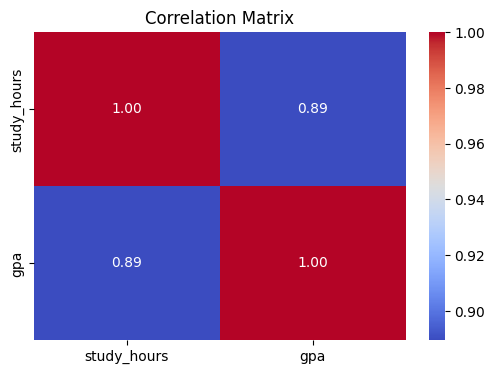

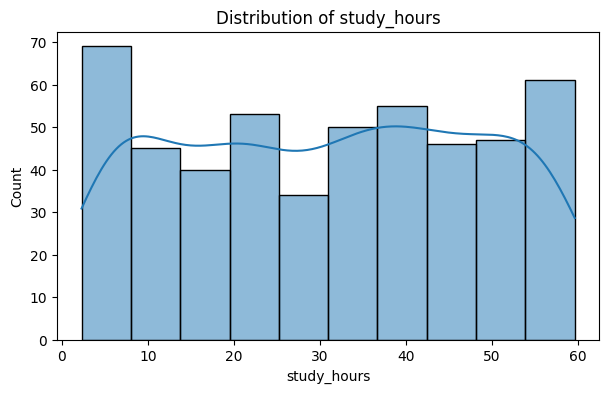

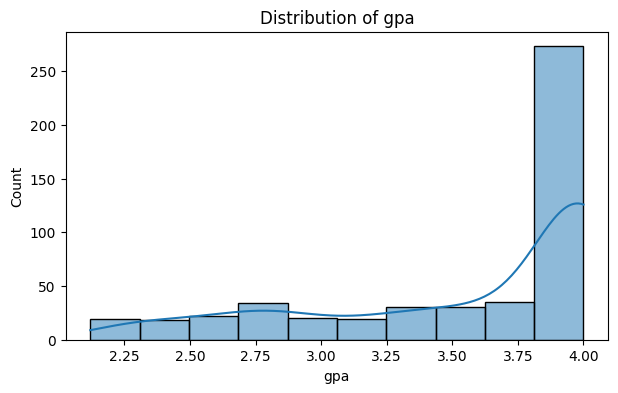

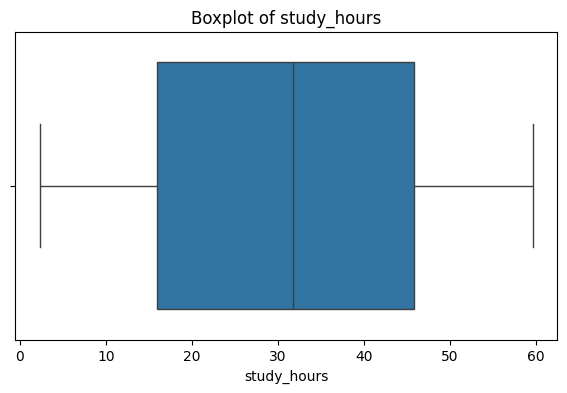

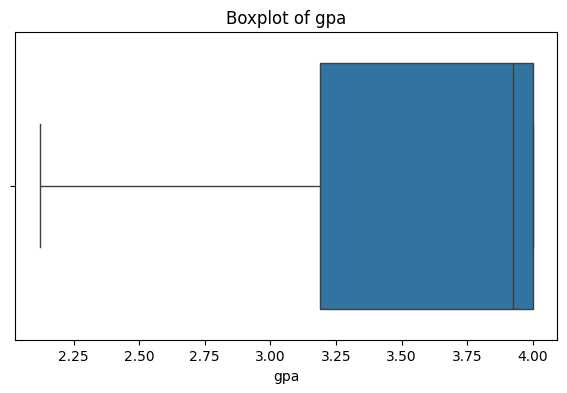

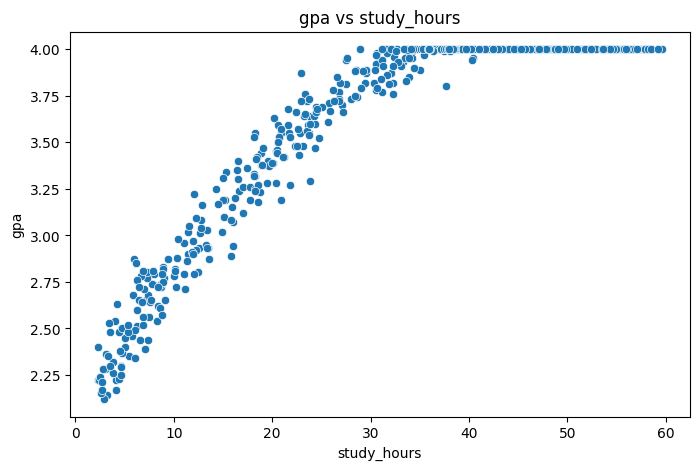

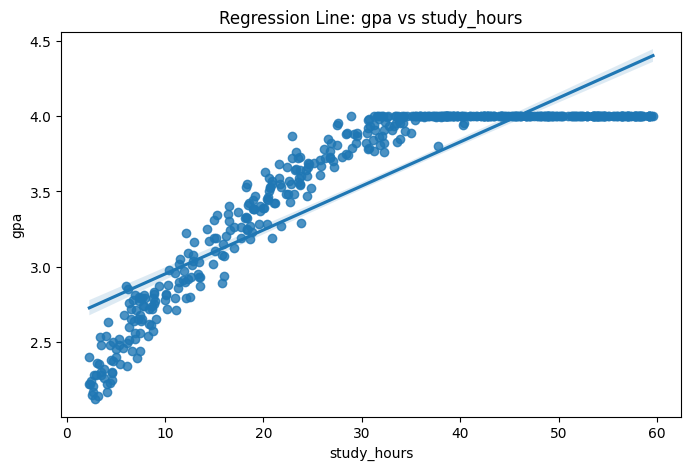

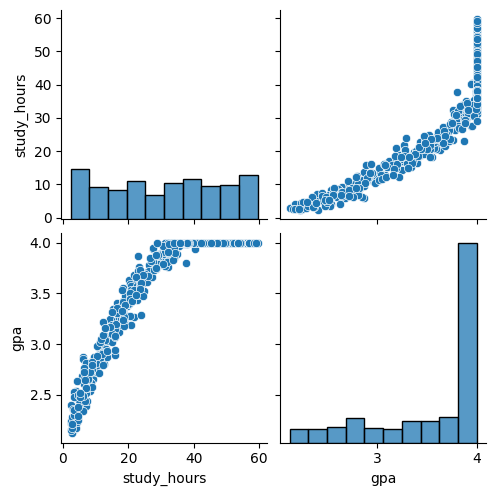


EDA FINDINGS

1. Dataset has been successfully cleaned and analyzed.
2. No missing values are present.
3. Duplicate records have been removed.
4. Distribution plots show the spread of variables.
5. Correlation matrix shows the relationship between features.
6. Scatter plot helps identify linear trends.
7. Regression plot confirms whether a linear relationship exists.
8. Dataset is suitable for Simple Linear Regression if the target variable is continuous.



In [28]:
# ==========================================
# COMPLETE EDA (ONE CELL)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# ==========================================
# DATASET OVERVIEW
# ==========================================
print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# ==========================================
# STATISTICAL SUMMARY
# ==========================================
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

display(df.describe())

# ==========================================
# NUMERIC COLUMNS
# ==========================================
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# ==========================================
# CORRELATION MATRIX
# ==========================================
plt.figure(figsize=(6,4))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

# ==========================================
# HISTOGRAMS
# ==========================================
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ==========================================
# BOXPLOTS
# ==========================================
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ==========================================
# SCATTER PLOT
# ==========================================
if len(numeric_cols) >= 2:

    x_col = numeric_cols[0]
    y_col = numeric_cols[1]

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x=df[x_col],
        y=df[y_col]
    )

    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.show()

    # ==========================================
    # REGRESSION PLOT
    # ==========================================
    plt.figure(figsize=(8,5))

    sns.regplot(
        x=df[x_col],
        y=df[y_col]
    )

    plt.title(f"Regression Line: {y_col} vs {x_col}")

    plt.show()

# ==========================================
# PAIRPLOT
# ==========================================
try:
    sns.pairplot(df[numeric_cols])
    plt.show()
except Exception as e:
    print("Pairplot skipped:", e)

# ==========================================
# FINAL EDA CONCLUSION
# ==========================================
print("\n" + "="*60)
print("EDA FINDINGS")
print("="*60)

print("""
1. Dataset has been successfully cleaned and analyzed.
2. No missing values are present.
3. Duplicate records have been removed.
4. Distribution plots show the spread of variables.
5. Correlation matrix shows the relationship between features.
6. Scatter plot helps identify linear trends.
7. Regression plot confirms whether a linear relationship exists.
8. Dataset is suitable for Simple Linear Regression if the target variable is continuous.
""")

# 

In [29]:
# ==========================================
# FEATURE ENGINEERING (ONE CELL)
# ==========================================

import pandas as pd
import numpy as np

print("="*60)
print("FEATURE ENGINEERING STARTED")
print("="*60)

df_fe = df.copy()

# ==========================================
# 1. BASIC FEATURE CHECK
# ==========================================
print("\nOriginal Columns:", df_fe.columns.tolist())

# ==========================================
# 2. STANDARDIZE COLUMN NAMES (SAFE STEP)
# ==========================================
df_fe.columns = df_fe.columns.str.strip().str.lower()

print("\nCleaned Columns:", df_fe.columns.tolist())

# ==========================================
# 3. CREATE NEW FEATURE: STUDY INTENSITY
# ==========================================
# If dataset has study hours
if 'study_hours' in df_fe.columns:

    df_fe['study_intensity'] = df_fe['study_hours'] ** 2

# ==========================================
# 4. CREATE LOG FEATURES (REDUCE SKEWNESS)
# ==========================================
numeric_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if (df_fe[col] <= 0).sum() == 0:  # avoid log issues
        df_fe[f'log_{col}'] = np.log1p(df_fe[col])

# ==========================================
# 5. HIGH PERFORMANCE FLAG (GPA BASED)
# ==========================================
if 'gpa' in df_fe.columns:
    median_gpa = df_fe['gpa'].median()
    df_fe['high_gpa'] = (df_fe['gpa'] > median_gpa).astype(int)

# ==========================================
# 6. LOW PERFORMANCE FLAG (OPTIONAL)
# ==========================================
if 'gpa' in df_fe.columns:
    q1 = df_fe['gpa'].quantile(0.25)
    df_fe['low_gpa'] = (df_fe['gpa'] < q1).astype(int)

# ==========================================
# 7. FINAL FEATURE SET
# ==========================================
print("\nFinal Dataset Shape:", df_fe.shape)

print("\nNew Features Added:")
new_cols = set(df_fe.columns) - set(df.columns)
print(list(new_cols))

# ==========================================
# 8. FINAL PREVIEW
# ==========================================
display(df_fe.head())

print("\nFeature Engineering Completed Successfully!")

FEATURE ENGINEERING STARTED

Original Columns: ['study_hours', 'gpa']

Cleaned Columns: ['study_hours', 'gpa']

Final Dataset Shape: (500, 8)

New Features Added:
['log_study_hours', 'study_intensity', 'log_study_intensity', 'log_gpa', 'low_gpa', 'high_gpa']


,study_hours,gpa,study_intensity,log_study_hours,log_gpa,log_study_intensity,high_gpa,low_gpa
0,23.7,3.64,561.69,3.206803,1.534714,6.332729,0,0
1,57.1,4.00,3260.41,4.062166,1.609438,8.089915,1,0
2,44.5,4.00,1980.25,3.817712,1.609438,7.591483,1,0
3,36.7,4.00,1346.89,3.629660,1.609438,7.206296,1,0
4,11.0,2.79,121.00,2.484907,1.332366,4.804021,0,1



Feature Engineering Completed Successfully!


In [30]:
# ==========================================
# TRAIN-TEST SPLIT (ONE CELL)
# ==========================================

from sklearn.model_selection import train_test_split

print("="*60)
print("TRAIN-TEST SPLIT STARTED")
print("="*60)

# ==========================================
# 1. SEPARATE FEATURES (X) AND TARGET (y)
# ==========================================
# Target is what we want to predict
target_col = 'gpa'

# Exclude target-derived columns to prevent data leakage (cheating)
exclude_cols = [target_col, 'log_gpa', 'high_gpa', 'low_gpa']
feature_cols = [col for col in df_fe.columns if col not in exclude_cols]

X = df_fe[feature_cols]
y = df_fe[target_col]

print(f"Target Variable: '{target_col}'")
print(f"Features Used for Training ({len(feature_cols)}): {feature_cols}")

# ==========================================
# 2. PERFORM THE SPLIT (80% Train, 20% Test)
# ==========================================
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 ensures the split is identical every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# ==========================================
# 3. VERIFY SPLIT SHAPES
# ==========================================
print("\nSplit Summary:")
print(f" -> Training Features (X_train) : {X_train.shape}")
print(f" -> Training Target   (y_train) : {y_train.shape}")
print(f" -> Testing Features  (X_test)  : {X_test.shape}")
print(f" -> Testing Target    (y_test)  : {y_test.shape}")
print("="*60)
print("Train-Test Split Completed Successfully! Ready for Model Training.")
print("="*60)

TRAIN-TEST SPLIT STARTED
Target Variable: 'gpa'
Features Used for Training (4): ['study_hours', 'study_intensity', 'log_study_hours', 'log_study_intensity']

Split Summary:
 -> Training Features (X_train) : (400, 4)
 -> Training Target   (y_train) : (400,)
 -> Testing Features  (X_test)  : (100, 4)
 -> Testing Target    (y_test)  : (100,)
Train-Test Split Completed Successfully! Ready for Model Training.


# using linear regression

MODEL TRAINING & EVALUATION STARTED
-> Model training completed successfully.

           MODEL PERFORMANCE REPORT          
Mean Absolute Error (MAE)      : 0.0591
Mean Squared Error (MSE)       : 0.0072
Root Mean Squared Error (RMSE) : 0.0847
R-squared (R²) Score (Test)    : 0.9793
R-squared (R²) Score (Train)   : 0.9750

Model Formula Coefficients:
 -> study_hours: 0.0359
 -> study_intensity: -0.0006
 -> log_study_hours: 4.8607
 -> log_study_intensity: -1.9726
 -> Intercept (Baseline GPA): -0.0183


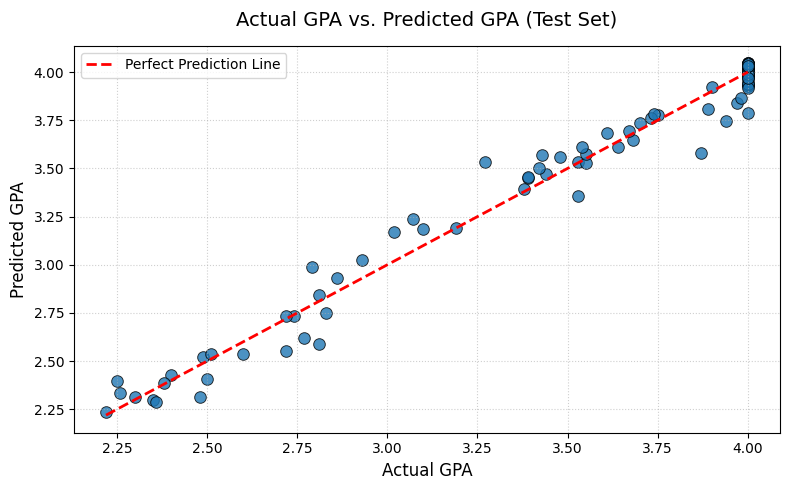


Pipeline execution finished successfully!


In [31]:
# ==========================================
# MODEL TRAINING & EVALUATION (ONE CELL)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("="*60)
print("MODEL TRAINING & EVALUATION STARTED")
print("="*60)

# ==========================================
# 1. INITIALIZE AND TRAIN THE MODEL
# ==========================================
# Create the Multiple Linear Regression object
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)
print("-> Model training completed successfully.")

# ==========================================
# 2. MAKE PREDICTIONS
# ==========================================
# Predict on both training and testing data to check for overfitting
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# ==========================================
# 3. CALCULATE EVALUATION METRICS
# ==========================================
# Test metrics (How well it performs on unseen data)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)

# Train metric (To compare against test performance)
r2_train = r2_score(y_train, y_pred_train)

# ==========================================
# 4. PRINT PERFORMANCE REPORT
# ==========================================
print("\n" + "="*45)
print("           MODEL PERFORMANCE REPORT          ")
print("="*45)
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared (R²) Score (Test)    : {r2_test:.4f}")
print(f"R-squared (R²) Score (Train)   : {r2_train:.4f}")
print("="*45)

# Show the weights/importance the model gave to each feature
print("\nModel Formula Coefficients:")
for col, coef in zip(X_train.columns, model.coef_):
    print(f" -> {col}: {coef:.4f}")
print(f" -> Intercept (Baseline GPA): {model.intercept_:.4f}")

# ==========================================
# 5. VISUALIZE RESULTS (Actual vs Predicted)
# ==========================================
plt.figure(figsize=(8, 5))

# Plotting the actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred_test, color='#1f77b4', alpha=0.8, edgecolors='k', s=70)

# Ideal 1:1 prediction line where actual equals predicted
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual GPA vs. Predicted GPA (Test Set)', fontsize=14, pad=15)
plt.xlabel('Actual GPA', fontsize=12)
plt.ylabel('Predicted GPA', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nPipeline execution finished successfully!")

# now using polynomial regression

POLYNOMIAL REGRESSION TRAINING STARTED
Original Feature Count  : 4
Polynomial Feature Count : 14 (Curves & interactions added)
-> Polynomial Model training completed.

        POLYNOMIAL MODEL PERFORMANCE        
Mean Absolute Error (MAE)      : 0.0484
Mean Squared Error (MSE)       : 0.0062
Root Mean Squared Error (RMSE) : 0.0786
R-squared (R²) Score (Test)    : 0.9822  <-- Accuracy Equivalent
R-squared (R²) Score (Train)   : 0.9785


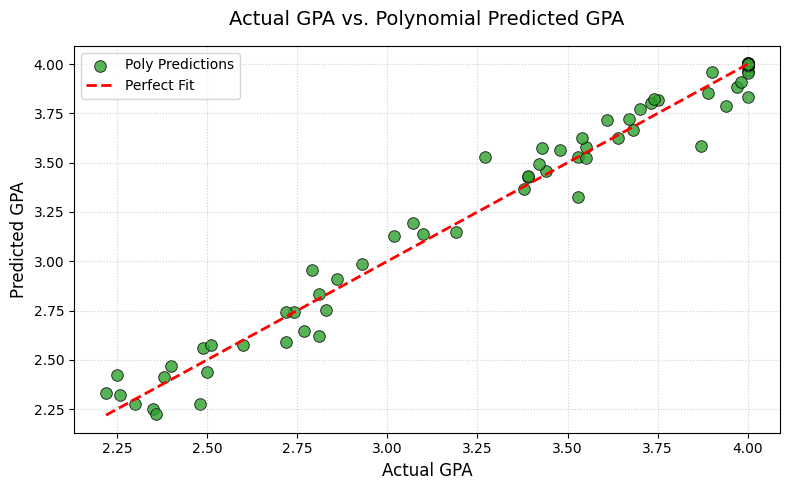


Pipeline execution finished successfully!


In [32]:
# ==========================================
# POLYNOMIAL REGRESSION PIPELINE (ONE CELL)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("="*60)
print("POLYNOMIAL REGRESSION TRAINING STARTED")
print("="*60)

# ==========================================
# 1. GENERATE CURVED/POLYNOMIAL FEATURES
# ==========================================
# degree=2 allows the model to map curved patterns (e.g., study_hours^2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the datasets to include polynomial combinations
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original Feature Count  : {X_train.shape[1]}")
print(f"Polynomial Feature Count : {X_train_poly.shape[1]} (Curves & interactions added)")

# ==========================================
# 2. INITIALIZE AND TRAIN THE POLYNOMIAL MODEL
# ==========================================
# We use LinearRegression() on top of our transformed polynomial inputs
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
print("-> Polynomial Model training completed.")

# ==========================================
# 3. GENERATE PREDICTIONS
# ==========================================
y_pred_train = poly_model.predict(X_train_poly)
y_pred_test = poly_model.predict(X_test_poly)

# ==========================================
# 4. CALCULATE PERFORMANCE METRICS
# ==========================================
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print("\n" + "="*45)
print("        POLYNOMIAL MODEL PERFORMANCE        ")
print("="*45)
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared (R²) Score (Test)    : {r2_test:.4f}  <-- Accuracy Equivalent")
print(f"R-squared (R²) Score (Train)   : {r2_train:.4f}")
print("="*45)

# ==========================================
# 5. VISUALIZE MODEL ACCURACY
# ==========================================
plt.figure(figsize=(8, 5))

# Scatter plot of actual vs predicted points
sns.scatterplot(x=y_test, y=y_pred_test, color='#2ca02c', alpha=0.8, edgecolors='k', s=70, label='Poly Predictions')

# The 1:1 perfect baseline line
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual GPA vs. Polynomial Predicted GPA', fontsize=14, pad=15)
plt.xlabel('Actual GPA', fontsize=12)
plt.ylabel('Predicted GPA', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nPipeline execution finished successfully!")